In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

In [2]:
# generating parameters and creating initial state
T1 = 50
T2 = 25
# T1 = 16
# T2 = 8
N = 5
dim = 2
trotter_dt = .02
psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel, phase_damp_channel],
    trotter_dt=trotter_dt,
)
# trotter = TrotterGroup(
#     continuous_operators=[amp_damp_channel],
#     trotter_dt=trotter_dt,
# )


# qt.Qobj(amp_damp_channel._create_single_qubit_operators(T1=1)[1])
# identity = qt.qeye(dim ** N)

In [3]:
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_62215/2826208940.py:2: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_62215/2826208940.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_62215/2826208940.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instea

In [4]:
# creating the initial state and encoding it 
psi0 = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 
# store the states and the fidelities that come out
states = []
fids = []
states.append(rho_encoded)
fids.append(qt.fidelity(rho_encoded_traced, rho_encoded_traced))

In [5]:
# run the circuit 
initial_time = .02
initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
for i in range(len(initial_state_relax)):
    a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
    states.append(initial_state_relax[i])
    fids.append(qt.fidelity(a, rho_encoded_traced))

# now apply the cnots to the circuit 
cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

syndrome_time = .4
after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
for i in range(len(after_syndrome_extraction)):
    a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
    states.append(after_syndrome_extraction[i])
    fids.append(qt.fidelity(a, rho_encoded_traced))

In [6]:
len(initial_state_relax)

1

In [7]:
# projective measurement 
projection_operator_00 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))
projection_operator_01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))
projection_operator_10 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())) 
projection_operator_11 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))


In [8]:
prob00 = projection_operator_00 * rho_encoded * projection_operator_00.dag()
prob01 = projection_operator_01 * rho_encoded * projection_operator_01.dag()
prob10 = projection_operator_10 * rho_encoded * projection_operator_10.dag()
prob11 = projection_operator_11 * rho_encoded * projection_operator_11.dag()

In [9]:
# apply the recovery gate
# measurement step is instantaneous 
rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

# now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
# correction_operators
r00 = qt.tensor(qt.qeye(dim ** N))
r01 = qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3))).full())
r10 = qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4))).full())
r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2))).full())


In [10]:
qt.ptrace(states[-1], [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[4.07450116e-09 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.67877067e-06 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.67877067e-06 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.67295965e-03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  2.67877067e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.67295965e-03 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.67295965e-03 0.00000000e+00]
 [0.00000000e+00 0.0000

In [9]:
# recovery algorithm
correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
                 r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
                 r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
                 r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
)

recovery_time = .05
# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
recovery1 = trotter.apply(rho_encoded, duration=recovery_time, discrete_unitary=r00)
# states.extend(recovery1)
# fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

# have to add them back to get the overall density matrix 
for i in range(len(recovery1)):
    total_state = (np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag()) * recovery1[i] + 
                   np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag()) * recovery2[i] + 
                   np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag()) * recovery3[i] + 
                   np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag()) * recovery4[i])
    total_state_normal = total_state / np.trace(total_state)
    total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
    states.append(total_state_normal)
    fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))

total_time = recovery_time + syndrome_time + initial_time

In [10]:
np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())

(0.0009180500781683746+0j)

In [11]:
np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())

(0.0009180500781683745+0j)

In [12]:
np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

(0.0009170185950231808+0j)

In [13]:
# trace out the ancillas
state_new = []
for i in range(len(states)):
    state_new.append(qt.ptrace(states[i], [0, 1, 2]))

In [14]:
time = np.linspace(0, total_time, len(states))
state_new[-1]

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1.89368839e-06+0.00000000e+00j 0.00000000e+00+2.04991104e-11j
  0.00000000e+00+2.05232700e-11j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+2.89270822e-11j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00-2.04991104e-11j 4.52160240e-07+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+2.89001059e-11j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+3.80359798e-11j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00-2.05232700e-11j 0.00000000e+00+0.00000000e+00j
  1.35678587e-08+0.00000000e+00j 0.00000000e+00+2.88730257e-11j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+2.04962937e-11j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00-2.89001059e-11j
  0.00000000e+00-2.88730257e-11j 1.60958691e-04+0.00000000e+00j

/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


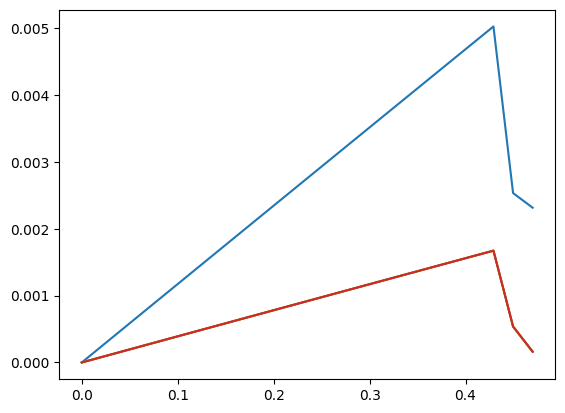

In [15]:
# graph the results
fig, ax = plt.subplots()
for i in [7,3,5,6]:
    data = []
    for j in range(len(state_new)):
    #     if i != 7:
    #         data.append(state_new[j][i, i])
    #     elif i == 7:
    #         data.append(1 - state_new[j][i, i])
        if i != 7:
            data.append(state_new[j][i,i])
        elif i == 7:
            data.append(1 - state_new[j][i,i])
    ax.plot(time, data)

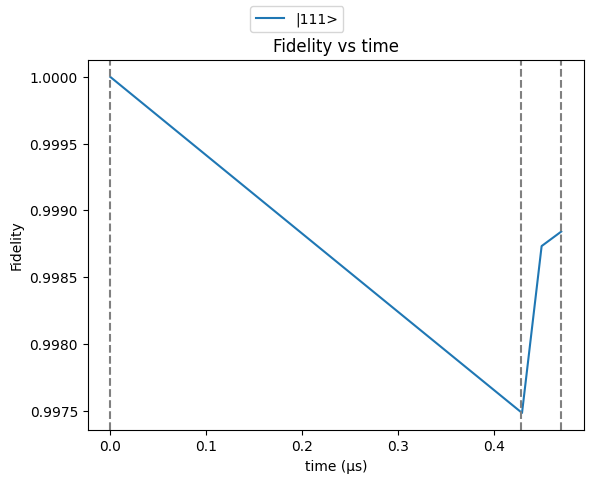

In [16]:
# fidelity plots 
fig, ax = plt.subplots()
ax.plot(time, fids, label = "|111>")

ax.set_title("Fidelity vs time")
ax.set_ylabel("Fidelity")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

stages = [0, .428, .47]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

# add vertical lines and the plots are then ready 

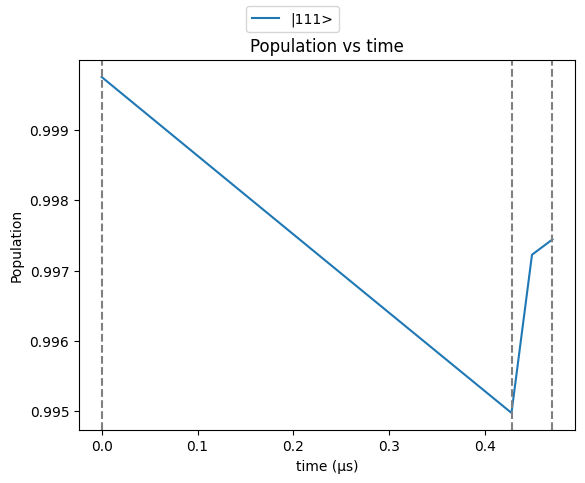

In [18]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_new)):
    data.append(state_new[i][7, 7])
ax.plot(time, data, label = "|111>")

ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

stages = [0, .428, .47]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

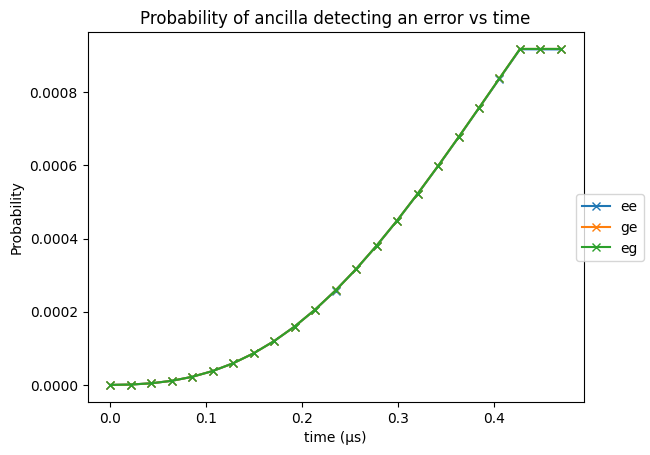

In [ ]:
# getting the probability that the ancillas measure a syndrome 
# states is the function that holds the states as a function o
prob_gg = []
prob_ge = []
prob_eg = []
prob_ee = []

state_gg = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)).dag()
state_ge = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)).dag()
state_eg = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)).dag()
state_ee = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)).dag()
for i in states:
    reduced_state = qt.ptrace(i, [3, 4])
    prob_gg.append((state_gg * reduced_state).tr())
    prob_ge.append((state_ge * reduced_state).tr())
    prob_eg.append((state_eg * reduced_state).tr())
    prob_ee.append((state_ee * reduced_state).tr())

probs = [prob_gg, prob_ge, prob_eg, prob_ee]

fig, ax = plt.subplots()
# for i in probs:
#     ax.plot(time, i)
# ax.plot(time, prob_ge)
# ax.plot(time, prob_eg)
ax.plot(time, prob_ee, marker = "x", label = "ee")
ax.plot(time, prob_ge, marker = "x", label = "ge")
ax.plot(time, prob_eg, marker = "x", label = "eg")
    
# seems reasonable 
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Probability")
ax.set_title("Probability of ancilla detecting an error vs time")
fig.legend(loc = "center right")

In [ ]:
compare_state = []
compare_fids = []
# total_time = 500
total_time = 195.99
rho_plot = trotter.apply(rho_encoded, duration=total_time, discrete_unitary=qt.qeye(dim  ** N))
for i in range(len(rho_plot)):
    a = qt.ptrace(rho_plot[i], [0, 1, 2])
    compare_state.append(a)
    compare_fids.append(qt.fidelity(a, rho_encoded_traced))


In [ ]:
compare_fids[-1]

0.30857636583629466

In [ ]:
time = np.linspace(0, total_time, len(compare_state))

83.33039371406906


/Users/girgis/Documents/GitHub/quantum_logical/venv/lib/python3.9/site-packages/numpy/lib/function_base.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


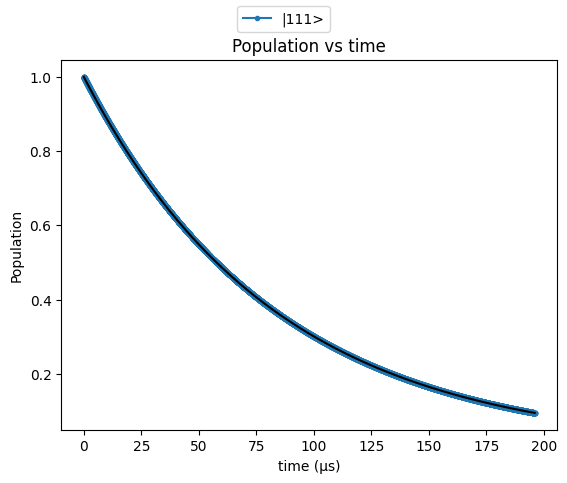

In [ ]:
fig, ax = plt.subplots()
# can change the data in the ax function to compare fids in order to get results for the fids
data = []
for i in range(len(compare_state)):
    data.append(compare_state[i][7, 7])
ax.plot(time, data, label = "|111>", marker = ".")

ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")

# fitting the data
def function_fit(t, b):
    return np.exp(-t / b)

parameters, covariance = curve_fit(function_fit, time, data)

fit_func = function_fit(time, parameters[0])
ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


T1_idle = parameters[0]
print(parameters[0]) 

In [ ]:
# make a fidelity vs iterations for these it should not be too hard make a stabilizer function and take data from that and plot it 
# this may be easy to do with fidelity instead of the state and this may give a result that makes sense 
def stabilizer(initial_state, check_state, time_list):
    fids = []
    states = []

    # run the circuit 
    initial_time = time_list[0]
    initial_state_relax = trotter.apply(initial_state, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
    for i in range(len(initial_state_relax)):
        a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
        states.append(initial_state_relax[i])
        fids.append(qt.fidelity(a, check_state))

    # now apply the cnots to the circuit 
    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

    syndrome_time = time_list[1]
    after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
        states.append(after_syndrome_extraction[i])
        fids.append(qt.fidelity(a, check_state))


    # apply the recovery gate
    # measurement step is instantaneous 
    rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
    rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
    rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
    rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

    # now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
    # correction_operators
    r00 = qt.tensor(qt.qeye(dim ** N))
    r01 = qt.Qobj((qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim ** 3))).full())
    r10 = qt.Qobj((qt.tensor(x_gate, qt.qeye(dim ** 4))).full())
    r11 = qt.Qobj((qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.qeye(dim ** 2))).full())


    # recovery algorithm
    # correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
    #                 r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
    #                 r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
    #                 r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
    # )

    recovery_time = time_list[2]
    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
    # states.extend(recovery1)
    # fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery1)):
        total_state = (np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag()) * recovery1[i] + 
                    np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag()) * recovery2[i] + 
                    np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag()) * recovery3[i] + 
                    np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag()) * recovery4[i])
        total_state_normal = total_state / np.trace(total_state)
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        states.append(total_state_normal)
        fids.append(qt.fidelity(total_state_trace, check_state))

    

    return states, fids

    

In [ ]:
result_states = []
result_fids = []
# result_fids.append(1)

time_list = [.02, .4, .05]

# doing stabilizers for multiple iterations
iterations = 417
# iterations = 726
iter_list = [] # for graphing purposes 

# building the data
for i in tqdm(range(iterations)):
    iter_list.append(i)
    a, b = stabilizer(initial_state=rho_encoded, check_state=rho_encoded_traced, time_list=time_list)
    c = b[-1]
    result_states.extend(a)
    result_fids.append(c)
    rho_encoded = result_states[-1]

  0%|          | 0/417 [00:00<?, ?it/s]

 72%|███████▏  | 299/417 [00:24<00:12,  9.69it/s]

 73%|███████▎  | 304/417 [00:25<00:16,  7.02it/s]

In [ ]:
# create the list of time for the amount of iterations
total_time = iterations * sum(time_list)

time_plot = np.linspace(0, total_time, len(result_states))

# analyze the data
plotted_fids = []
for i in range(int(len(result_fids) / 4)):
    plotted_fids.append(result_fids[i * 4 + 3])  

# trace out the ancillas
state_sim = []
for i in range(len(result_states)):
    state_sim.append(qt.ptrace(result_states[i], [0, 1, 2]))

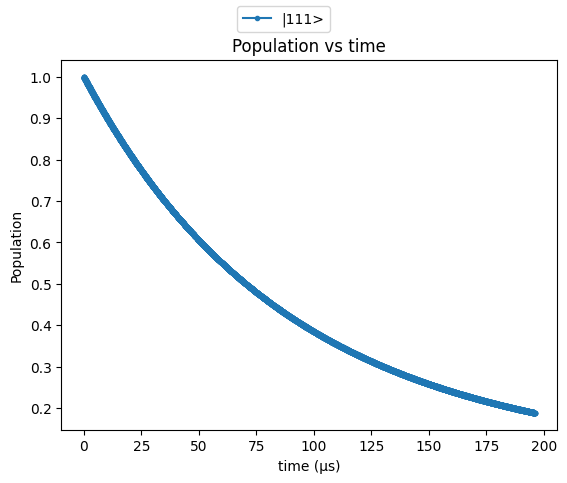

In [ ]:
# state vs time 
fig, ax = plt.subplots()
datas = []
for j in range(len(state_sim)):
    datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(time_plot, datas, label = "|111>", marker = ".")

ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")

# fitting the data
# def function_fit(t, b):
#     return np.exp(-t / b)

# parameters, covariance = curve_fit(function_fit, time_plot, datas)

# fit_func = function_fit(time_plot, parameters[0])
# ax.plot(time_plot, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_stabilizer = parameters[0]
# print(parameters[0]) 

In [ ]:
beta = 101 / T1_idle
beta

1.2120427553307924

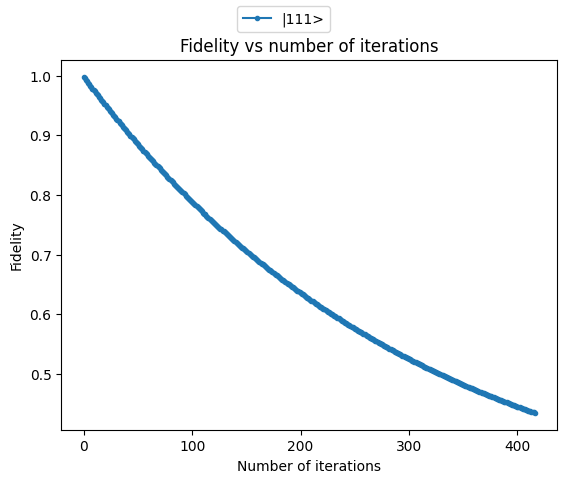

In [ ]:
# fidelity vs iterations
fig, ax = plt.subplots()
datas = []
# for j in range(len(state_sim)):
#     datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(iter_list, result_fids, label = "|111>", marker = ".")

ax.set_xlabel("Number of iterations")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs number of iterations")

fig.legend(loc = "upper center")

In [ ]:
result_fids[-1]

0.43454186933798966

In [ ]:
0.43454186933798966

0.43454186933798966

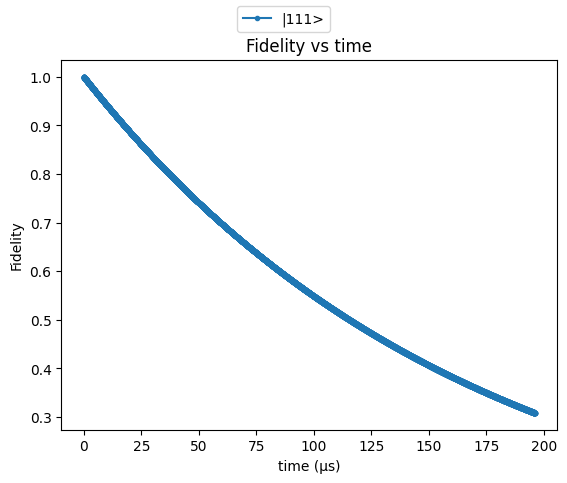

In [ ]:
fig, ax = plt.subplots()
datas = []
# for j in range(len(state_sim)):
#     datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(time, compare_fids, label = "|111>", marker = ".")
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs time")
# label this as idle 

fig.legend(loc = "upper center")